In [21]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np



In [22]:
sentences = [
   # Cricket (4)
   "Virat Kohli scored a century in the match",
   "The bowler took three wickets in one over",
   "Cricket is very popular in India",
   "The team won the match by five runs",

   # Cooking (3)
   "I cooked pasta with tomato sauce",
   "Frying vegetables improves taste",
   "Baking requires precise temperature control",

   # Cybersecurity (3)
   "Strong passwords protect your accounts",
   "Hackers try to exploit system vulnerabilities",
   "Cybersecurity helps prevent data breaches"
]

In [23]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


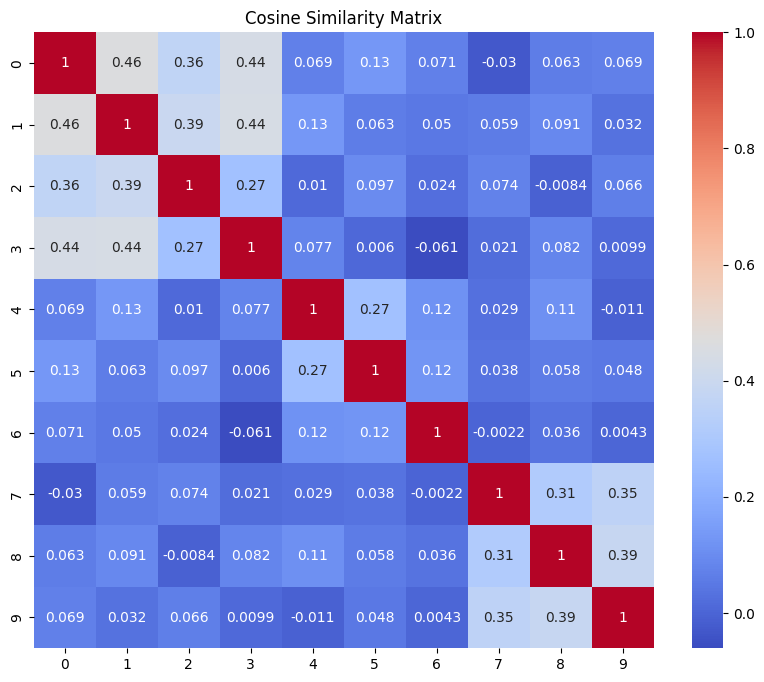

In [24]:
similarity_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(10,8))
sns.heatmap(similarity_matrix, annot=True, cmap='coolwarm')
plt.title("Cosine Similarity Matrix")
plt.show()

In [25]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])
scores = cosine_similarity(query_embedding, embeddings)[0]

top_indices = np.argsort(scores)[-2:][::-1]

print("Top 2 similar sentences:\n")

for i in top_indices:
   print("Sentence:", sentences[i])
   print("Similarity Score:", round(scores[i], 4))
   print()

Top 2 similar sentences:

Sentence: The bowler took three wickets in one over
Similarity Score: 1.0

Sentence: Virat Kohli scored a century in the match
Similarity Score: 0.4623

